# Module 10 Lab - Unsupervised Learning**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised LearningSo far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.Two major types of unsupervised learning are:*   **Clustering:** Automatically grouping similar data points together.*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:1.  Randomly placing `k` centroids (the center of a cluster) in the data.2.  **Assignment Step:** Assigning each data point to its nearest centroid.3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.4.  Repeating steps 2 and 3 until the centroids stop moving.**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

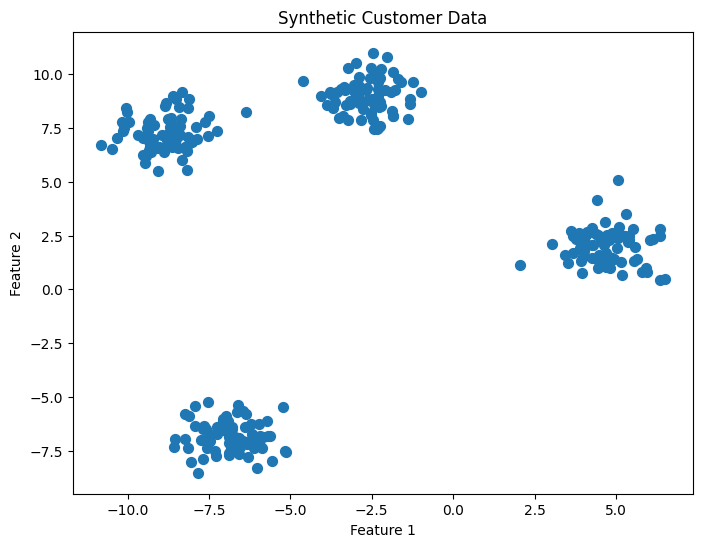

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

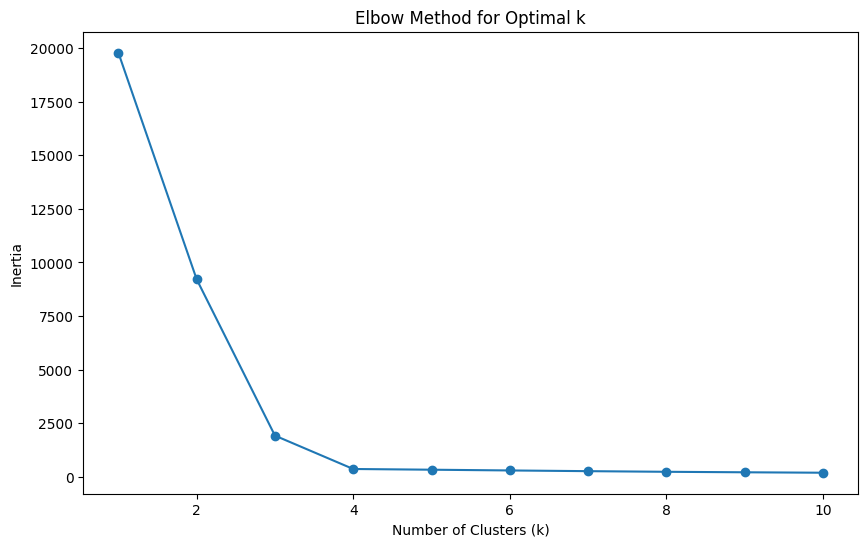

In [8]:
from sklearn.cluster import KMeans

# --- ENTER YOUR CODE HERE ---
# 1. Create an empty list to store the inertia values
inertia = []

# 2. Loop through k values from 1 to 10
for k in range(1, 11):
    # 3. Create and fit a KMeans model with `n_clusters=k`
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # 4. Append the model's inertia_ to your list
    inertia.append(kmeans.inertia_)

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### Task 2: Perform K-Means Clustering and VisualizeFrom the elbow plot, it looks like `k=4` is the optimal number of clusters.**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

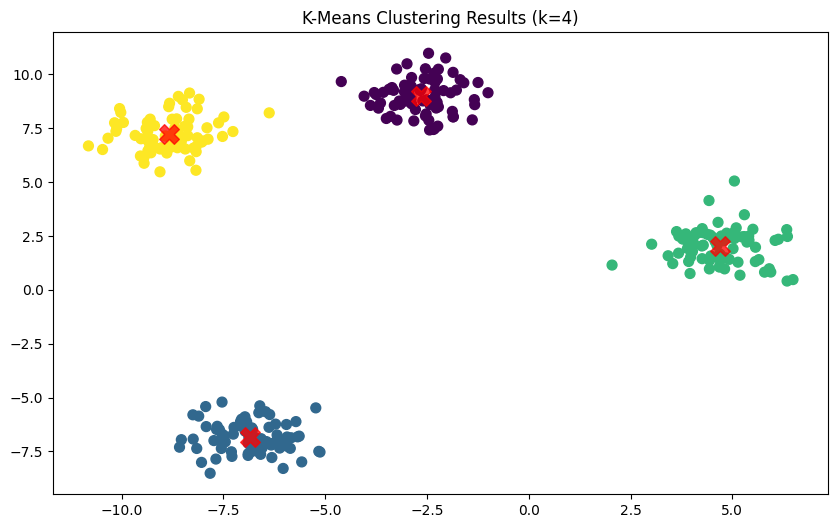

In [9]:
# --- ENTER YOUR CODE HERE ---
# 1. Create and fit a KMeans model with n_clusters=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)
# 2. Get the cluster assignments for each data point
labels = kmeans.labels_
# 3. Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_
# 4. Create a scatter plot of the data, colored by the labels
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X') # Plot the centers
plt.title('K-Means Clustering Results (k=4)')
plt.show()

## Part 3: Principal Component Analysis (PCA)**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.**Use Cases:***   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.*   **Performance:** Speeding up model training by using fewer features.**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


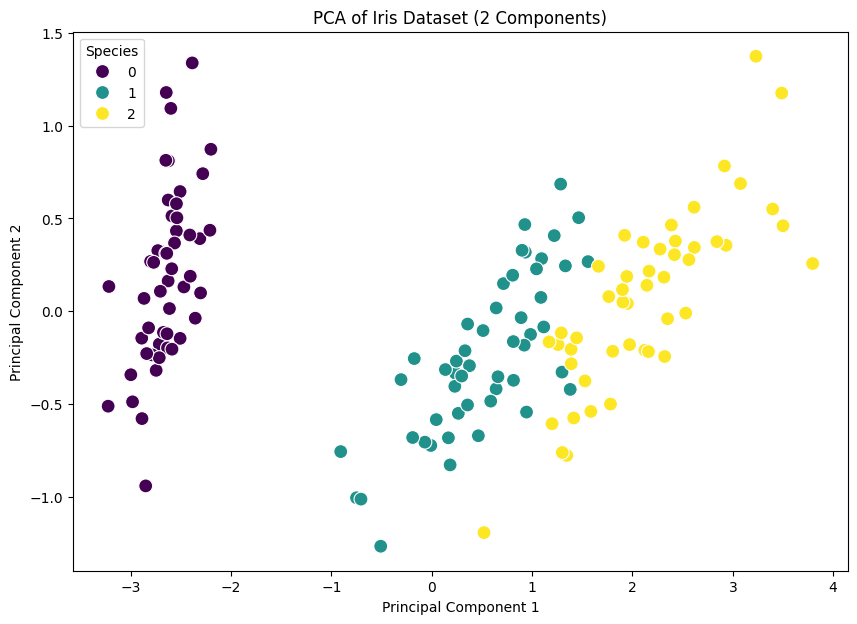

In [10]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# --- ENTER YOUR CODE HERE ---
# 1. Create a PCA instance to reduce to 2 components
pca = PCA(n_components=2)
# 2. Fit PCA to the data and transform it
X_pca = pca.fit_transform(X_iris)
# 3. Print the explained variance ratio
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")
# 4. Create a DataFrame with the PCA results for plotting
pca_df = pd.DataFrame(data=X_pca, columns=["Principal Component 1", "Principal Component 2"])
pca_df["Species"] = y_iris
# 5. Plot the results
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Principal Component 1", y="Principal Component 2", hue="Species", data=pca_df, palette='viridis', s=100)
plt.title('PCA of Iris Dataset (2 Components)')
plt.show()

## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.
1.  **What is the fundamental difference between supervised and unsupervised learning?**
2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**
3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**

**[ENTER YOUR ANSWERS HERE]**

1.  **What is the fundamental difference between supervised and unsupervised learning?**
    *   **Supervised Learning:** This is like learning with a teacher. You have a dataset where you know both the input features (X) and the correct output (y), which is called the 'label' or 'target'. The goal is to learn a rule that maps the inputs to the correct outputs, so you can predict outputs for new, unseen inputs.
    *   **Unsupervised Learning:** This is like learning without a teacher. You only have the input features (X), and there are no correct answers or labels. The goal is to find hidden patterns, structures, or groupings within the data on its own.

2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**
    *   If we choose the largest possible `k` (where `k` is the number of clusters), we could end up with a situation where each data point becomes its own cluster. In this case, the inertia (which measures how close points are to their cluster center) would be very, very low, maybe even zero. However, this wouldn't be useful for finding meaningful groups or patterns in the data. The goal of clustering is to simplify the data into a few meaningful groups, not to just isolate every single data point. The 'elbow' point helps us find a good balance: a low inertia without having too many clusters that don't provide new insights.

3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**
    *   This means that even though the Iris dataset originally had 4 different features (dimensions), almost all the important information and variability in the data can be captured by just 2 new features (the principal components). Imagine a 4-dimensional shape; PCA found a way to project that shape onto a 2-dimensional plane (like a flat piece of paper) while still retaining over 95% of its 'spread' or differences. This is great because it allows us to visualize and analyze the data much more easily in 2D without losing much of its original richness or meaning.

## 🧠 Reflective Journal - Unsupervised Learning for Beginners

In this lab, **Unsupervised Learning** was explored. It differs from supervised learning, which relies on labeled data to guide models.

### K-Means Clustering

*   **Key learning:** K-Means helps identify groups (clusters) in data even when those groups are not known beforehand. This process is akin to categorizing items without predefined labels.
*   **The Elbow Method:** This method assists in determining an appropriate number of clusters (`k`). It involves observing a plot where the rate of decrease in inertia (a measure of cluster compactness) slows, indicating a suitable `k` value.
*   **Observations:** For the customer data, `k=4` was selected. The visualization clearly showed how the algorithm segmented the data points into distinct groups, revealing underlying patterns.

### Principal Component Analysis (PCA)

*   **Key learning:** PCA is a technique for reducing data dimensionality while preserving essential information. It transforms high-dimensional data into a lower-dimensional representation.
*   **Observations:** The Iris dataset, originally with 4 features, was reduced to 2 principal components using PCA. These two components explained over 95% of the data's variance. This reduction simplifies visualization, allowing the different Iris species to be clearly separated on a 2D scatter plot, thereby making complex data more accessible.

### Overall Reflection

This lab demonstrated how insights can be found in data without pre-existing labels. Clustering can be used for tasks like customer segmentation, and PCA is valuable for simplifying and visualizing complex datasets. These techniques offer practical applications for data analysis.